In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('1-studyhours.csv')
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [4]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


In [5]:
df.isnull().sum()

Study Hours    0
Exam Score     0
dtype: int64

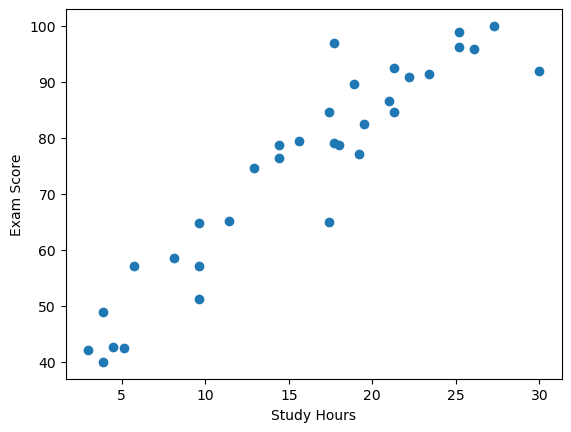

In [6]:
plt.scatter(df["Study Hours"], df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

In [7]:
# independent(X) and dependent(y) feature 
X = df[["Study Hours"]] # DataFrame olması istenir
y = df["Exam Score"]    # Series olması istenir

In [8]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [9]:
# Test - Train Split

from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [11]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [12]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [13]:
# standardize the data set

from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   # no fit -> data leakage (veri sızıntıs)

X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

# Mülakatta Çıkabilecek Sorular

### 1- Neden Scaler kullanırız?

Farklı kolonlarda değer aralıkları çok farklı olabilir (ör: yaş 20–60, maaş 3000–50000).

Bu farklar, özellikle mesafe tabanlı algoritmalar (KNN, SVM) ve gradient descent kullanan yöntemlerde (lojistik regresyon, yapay sinir ağları) modelin dengesiz öğrenmesine yol açabilir.

Scaler kullanarak tüm değişkenleri benzer ölçeklere indirgeriz → böylece daha hızlı ve daha kararlı optimizasyon sağlanır.

### 2- fit_transform ve transform farkı nedir?

fit → veriden ölçekleme parametrelerini (ortalama, standart sapma, min–max değerleri) öğrenir.

transform → öğrenilen parametrelere göre veriyi dönüştürür.

Eğitim setinde fit_transform, test setinde ise yalnızca transform kullanılır.

Bunun sebebi: Test verisinin dağılımını öğrenip modele ipucu vermek istemeyiz → veri sızıntısını önlemek gerekir.

### Terimler

**Gradient Descent (Gradyan İnişi)**

Makine öğrenmesinde maliyet fonksiyonunu (loss) en aza indirmek için kullanılan optimizasyon algoritmasıdır.

Fonksiyonun türevini (gradyanını) alıp, en dik iniş yönünde küçük adımlarla parametreleri günceller.

Amaç: model parametrelerini (ağırlıkları) doğru değerlere yaklaştırmaktır.

Öğrenme hızı (learning rate) çok yüksek olursa minimumu ıskalar, çok düşük olursa öğrenme çok yavaşlar.

👉 Kısaca: “Gradient descent, modeli kaybı en aza indirecek şekilde adım adım optimize eden bir yöntemdir.”

**Data Leakage (Veri Sızıntısı)**

Eğitim sırasında modele gelecekteki bilgilerin yanlışlıkla sızması durumudur.

Örnek: Test setini scaler’a fit etmek → model test verisinin dağılımını öğrenmiş olur.

Sonuç: Eğitim sırasında test verisini görmüş gibi davranır → yapay olarak yüksek doğruluk, ama gerçek dünyada başarısızlık.

👉 Kısaca: “Data leakage, modelin aslında erişememesi gereken bilgileri öğrenmesi ve bu yüzden sahte bir başarı göstermesidir.”

# Model

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
regression = LinearRegression()

In [17]:
regression.fit(X_train, y_train)

LinearRegression()

In [18]:
print("Coefficient (Katsayı): ", regression.coef_)
print("Intercept: ", regression.intercept_)

Coefficient (Katsayı):  [16.17860223]
Intercept:  76.9076923076923


In [19]:
# y = 76.91 + 16.18x

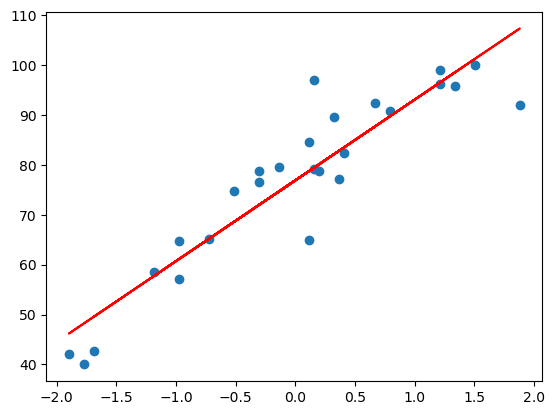

In [20]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), "r")
plt.show()

In [21]:
# x=20, y=?

regression.predict([[20]])

array([400.47973694])

In [22]:
scaler.transform([[20]])

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [23]:
regression.predict(scaler.transform([[20]])) # Exam Score: 84 

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [25]:
regression.predict(scaler.transform([[10]]))

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([62.05187491])

# Regresyon Başarım Metrikleri

Bir regresyon modelinin başarısını ölçmek için tahmin edilen değerler ile gerçek değerler arasındaki farklara bakılır. En yaygın metrikler:

### MAE (Mean Absolute Error)

Tahmin hatalarının mutlak değerlerinin ortalamasıdır.

Yorumu kolaydır: “Model tahminleri ortalama kaç birim yanılıyor?”

### MSE (Mean Squared Error)

Hataların karelerinin ortalamasıdır.

Büyük hataları daha fazla cezalandırır, ama birimi kareli olduğundan yorumu daha zor olabilir.

### RMSE (Root Mean Squared Error)

MSE’nin karekökü.

Hem büyük hataları cezalandırır hem de orijinal birimle ifade edilir.

### R² (Determination Coefficient)

Modelin veriyi ne kadar açıkladığını gösterir (0–1 arası).

1 → Mükemmel uyum, 0 → Hiçbir şey açıklamıyor.

Negatif çıkabilir (model çok kötü ise).

👉 Özetle:

MAE → Ortalama hata büyüklüğü

MSE / RMSE → Büyük hatalara daha duyarlı ölçümler

R² → Modelin açıklayıcılık gücü

In [27]:
# prediction with test data

y_pred_test = regression.predict(X_test)

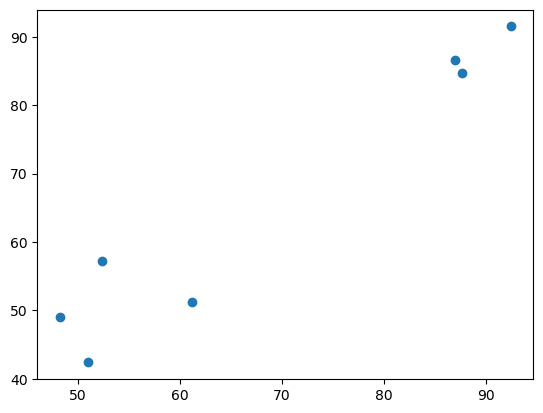

In [28]:
plt.scatter(y_pred_test, y_test)
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)
print("R2 SCORE: ",r2)

MSE:  29.45839048833392
MAE:  4.054868128856142
RMSE:  5.427558427906043
R2 SCORE:  0.9196596206825491
